In [1]:
import sqlite3
import duckdb
import re
import os

VLLM_ENDPOINT = "http://[200:2a83:16bc:667:23ed:dfbf:74ca:13da]:8000/v1"

In [2]:
if not os.path.exists("imdb.duckdb"):
    print("Downloading data...")
    !wget -O imdb.duckdb.zst -nc "https://www.dropbox.com/scl/fi/emi7nllwxiqxbv38mxgcb/imdb.duckdb.zst?rlkey=wo4eqcypnrv3x0ckydykup6nz&st=xpi0f01v"
    !unzstd -k imdb.duckdb.zst

In [3]:
con = duckdb.connect("imdb.duckdb")
all_tables = con.sql("select table_name from information_schema.tables").df()["table_name"].to_list()

In [4]:
#TODO support compound primary keys

primary_keys = con.sql("""
SELECT tc.table_name, c.column_name
FROM information_schema.table_constraints tc,
     information_schema.constraint_column_usage ccu,
     information_schema.columns as c,
WHERE tc.constraint_schema = ccu.constraint_schema
  AND tc.constraint_name = ccu.constraint_name
  AND c.table_schema = tc.constraint_schema
  AND tc.table_name = c.table_name 
  AND ccu.column_name = c.column_name
  AND tc.constraint_type = 'PRIMARY KEY';
""").df().set_index("table_name").to_dict()["column_name"]
primary_keys

{'aka_name': 'id',
 'aka_title': 'id',
 'cast_info': 'id',
 'char_name': 'id',
 'comp_cast_type': 'id',
 'company_name': 'id',
 'company_type': 'id',
 'complete_cast': 'id',
 'info_type': 'id',
 'keyword': 'id',
 'kind_type': 'id',
 'link_type': 'id',
 'movie_companies': 'id',
 'movie_info': 'id',
 'movie_info_idx': 'id',
 'movie_keyword': 'id',
 'movie_link': 'id',
 'name': 'id',
 'person_info': 'id',
 'role_type': 'id',
 'title': 'id'}

In [5]:
foreign_keys = con.sql("""
SELECT table_name, constraint_column_names, referenced_table, referenced_column_names FROM duckdb_constraints() c
WHERE c.constraint_type = 'FOREIGN KEY'
""").df()

foreign_keys = [(x['table_name'], x['referenced_table'],
                 f"{x['table_name']}.{x['constraint_column_names'][0]} = {x['referenced_table']}.{x['referenced_column_names'][0]}")
                 for _, x in foreign_keys.iterrows()]
foreign_keys

[('aka_name', 'name', 'aka_name.person_id = name.id'),
 ('aka_title', 'title', 'aka_title.movie_id = title.id'),
 ('aka_title', 'kind_type', 'aka_title.kind_id = kind_type.id'),
 ('cast_info', 'name', 'cast_info.person_id = name.id'),
 ('cast_info', 'title', 'cast_info.movie_id = title.id'),
 ('complete_cast', 'title', 'complete_cast.movie_id = title.id'),
 ('complete_cast',
  'comp_cast_type',
  'complete_cast.subject_id = comp_cast_type.id'),
 ('complete_cast',
  'comp_cast_type',
  'complete_cast.status_id = comp_cast_type.id'),
 ('movie_companies', 'title', 'movie_companies.movie_id = title.id'),
 ('movie_companies',
  'company_name',
  'movie_companies.company_id = company_name.id'),
 ('movie_companies',
  'company_type',
  'movie_companies.company_type_id = company_type.id'),
 ('movie_info', 'title', 'movie_info.movie_id = title.id'),
 ('movie_info', 'info_type', 'movie_info.info_type_id = info_type.id'),
 ('movie_info_idx', 'title', 'movie_info_idx.movie_id = title.id'),
 ('movi

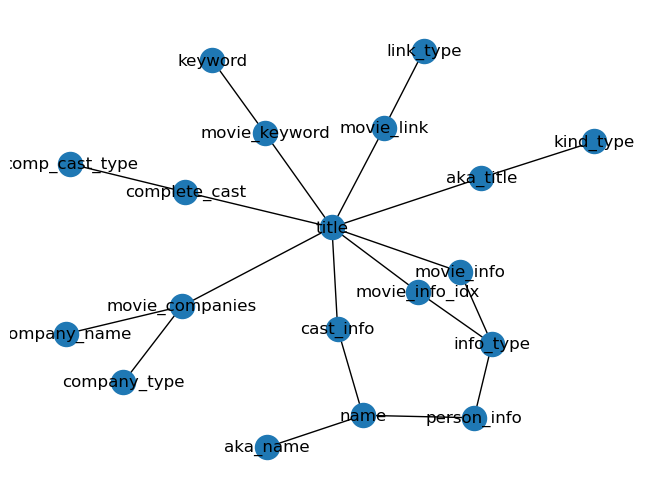

In [6]:
import networkx as nx

G = nx.Graph()

for s, d, w in foreign_keys:
    G.add_edge(s, d, label=w)

nx.draw(G, with_labels=True)

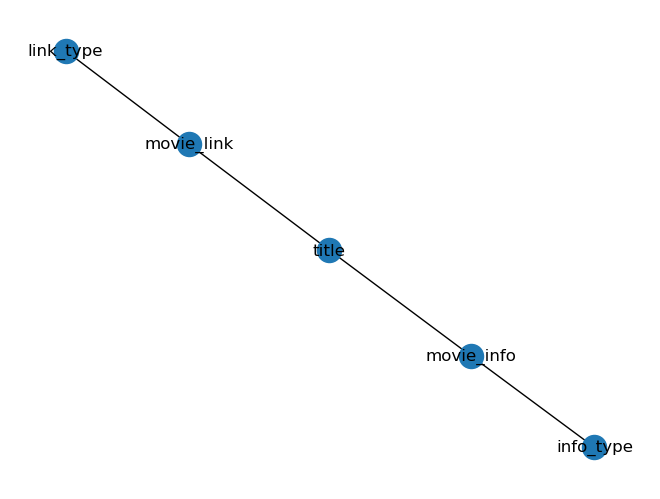

In [7]:
from networkx.algorithms import approximation
result = approximation.steiner_tree(G, ["title", "link_type", "info_type"])
nx.draw(result, with_labels=True)

In [8]:
con.sql("select column_name, column_type from (describe title) where key is null")

┌─────────────────┬─────────────┐
│   column_name   │ column_type │
│     varchar     │   varchar   │
├─────────────────┼─────────────┤
│ title           │ VARCHAR     │
│ imdb_index      │ VARCHAR     │
│ kind_id         │ INTEGER     │
│ production_year │ INTEGER     │
│ phonetic_code   │ VARCHAR     │
│ episode_of_id   │ INTEGER     │
│ season_nr       │ INTEGER     │
│ episode_nr      │ INTEGER     │
│ series_years    │ VARCHAR     │
└─────────────────┴─────────────┘

In [9]:

con.sql("select imdb_index, count(*) cnt from title group by imdb_index order by cnt desc limit 10 ")

┌────────────┬─────────┐
│ imdb_index │   cnt   │
│  varchar   │  int64  │
├────────────┼─────────┤
│            │ 2502042 │
│ I          │   11125 │
│ II         │   10946 │
│ III        │    2438 │
│ IV         │     876 │
│ V          │     394 │
│ VI         │     204 │
│ VII        │     110 │
│ VIII       │      55 │
│ IX         │      36 │
├────────────┴─────────┤
│ 10 rows    2 columns │
└──────────────────────┘

In [10]:
import json
string_col_schema = """
{
    "type": "object",
    "properties": {
      "column": { "type": "string", "const": "COL_NAME" },
      "filter": { "type": "string", "enum": ["random", "most_popular", "least_popular"] }
    },
    "required": ["column", "filter"],
    "additionalProperties": false
}
"""

int_col_schema = """
{
    "type": "object",
    "properties": {
      "column": { "type": "string", "const": "COL_NAME" },
      "op": { "type": "string", "enum": ["<", ">", "=", "!="] },
      "value": { "anyOf": [
          { "type": "number", "minimum": 0.0, "maximum": 1.0 },
          { "type": "string", "enum": ["most_popular", "least_popular"] }
      ]}
    },
    "required": ["column", "op", "value"],
    "additionalProperties": false
}
"""

table_schema = """
{
    "type": "object",
    "properties": {
        "table": { "type": "string", "const": "TABLE_NAME" },
        "filters": {
            "type": "array",
            "items": { "anyOf": COLUMN_SCHEMAS }
        }
    },
    "required": ["table"],
    "additionalProperties": false
}
"""
from jsonschema import validate


In [11]:
year_schema = json.loads(int_col_schema.replace("COL_NAME", "production_year"))
validate(instance={"column": "production_year", "op": "!=", "value": "most_popular"}, schema=year_schema)

In [12]:
cols = con.sql("select column_name, column_type from (describe title) where key is null").df()
col_schema = []
for _, d in cols.iterrows():
    cname = d["column_name"]
    ctype = d["column_type"]

    if ctype == "VARCHAR":
        col_schema.append(json.loads(string_col_schema.replace("COL_NAME", cname)))
    elif ctype == "INTEGER":
        col_schema.append(json.loads(int_col_schema.replace("COL_NAME", cname)))

col_schema = json.dumps(col_schema)
title_schema = table_schema.replace("TABLE_NAME", "title").replace("COLUMN_SCHEMAS", col_schema)
title_schema = json.loads(title_schema)

In [13]:
data = {"table": "title",
        "filters": [
            {"column": "title", "filter": "random"},
            {"column": "production_year", "op": "<", "value": 0.5}
        ]}
validate(instance=data, schema=title_schema)

In [2]:
import lark

gram = """
?start: title_selector?

?title_selector: "(title (" title_year_filter? title_ep_filter? "))"
?title_year_filter: "(year " intop " " intval ")"
?title_ep_filter: "(ep " strop ")"

?intop: "<" | ">" | "=" | "!="
?strop: "most_popular" | "random"

?intval: "first" | "median" | "last" | int int int
?int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"

"""

lark.Lark(gram)

Lark(open('<string>'), parser='earley', lexer='dynamic', ...)

In [15]:
def grammar_for_table(table):    
    cols = con.sql(f"select column_name, column_type from (describe {table}) where key is null").df()
    col_schema = []
    filter_rules = []
    filter_names = []
    for _, d in cols.iterrows():
        cname = d["column_name"]
        if cname.endswith("_id"):
            continue
        ctype = d["column_type"]
    
        filt_rule = f"{table}_{cname}_filter"
        if ctype == "VARCHAR":
            filter_rules.append(f"""{filt_rule}: "({cname} " strop ")" """)
        elif ctype == "INTEGER":
            filter_rules.append(f"""{filt_rule}: "({cname} " intop " " intval ")" """)
            
        filter_names.append(filt_rule)
    
    grammar = [
        f"""{table}_selector: "({table} " {" ".join(x + '?' for x in filter_names)} ")" """
    ]
    grammar.extend(filter_rules)
    grammar.append("")
    return grammar

grammar = ["start: " + " ".join(f"{x}_selector?" for x in all_tables)]
for table in all_tables:
    grammar.extend(grammar_for_table(table))

grammar = "\n".join(grammar)
grammar += """

intop: "<" | ">" | "=" | "!="
strop: "most_popular" | "random"

intval: "first" | "median" | "last" | "mode" | int int int int
int: "0" | "1" | "2" | "3" | "4" | "5" | "6" | "7" | "8" | "9"
"""

print(grammar)

start: aka_name_selector? aka_title_selector? cast_info_selector? char_name_selector? company_name_selector? company_type_selector? complete_cast_selector? comp_cast_type_selector? info_type_selector? keyword_selector? kind_type_selector? link_type_selector? movie_companies_selector? movie_info_selector? movie_info_idx_selector? movie_keyword_selector? movie_link_selector? name_selector? person_info_selector? role_type_selector? title_selector?
aka_name_selector: "(aka_name " aka_name_name_filter? aka_name_imdb_index_filter? aka_name_name_pcode_cf_filter? aka_name_name_pcode_nf_filter? aka_name_surname_pcode_filter? ")" 
aka_name_name_filter: "(name " strop ")" 
aka_name_imdb_index_filter: "(imdb_index " strop ")" 
aka_name_name_pcode_cf_filter: "(name_pcode_cf " strop ")" 
aka_name_name_pcode_nf_filter: "(name_pcode_nf " strop ")" 
aka_name_surname_pcode_filter: "(surname_pcode " strop ")" 

aka_title_selector: "(aka_title " aka_title_title_filter? aka_title_imdb_index_filter? aka_tit

In [16]:
parsing_grammar = """

start: selector+
selector: "(" ident " " filter* ")"
?ident: /[a-z0-9_]+/
filter: int_filter | str_filter
int_filter: "(" ident " " intop " " intval ")"
str_filter: "(" ident " " strop ")"

!intop: "<" | ">" | "=" | "!="
!strop: "most_popular" | "random"

!intval: "first" | "median" | "last" | "mode" | /[0-9]{4}/
"""

In [17]:
g = lark.Lark(parsing_grammar)
print(g.parse("(title (production_year = mode))").pretty())

start
  selector
    title
    filter
      int_filter
        production_year
        intop	=
        intval	mode



In [45]:
def get_int_value(table_name, field, value):
    if value == "first":
        r = con.sql(f"select {field} from {table_name} order by {field} limit 1")
        return str(r.df().to_numpy()[0][0])
    elif value == "median":
        r = con.sql(f"select median({field}) from {table_name}")
        return str(r.df().to_numpy()[0][0])
    elif value == "last":
        r = con.sql(f"select {field} from {table_name} order by {field} desc limit 1")
        return str(r.df().to_numpy()[0][0])
    elif value == "mode":
        r = con.sql(f"select {field} from {table_name} group by {field} order by count(*) desc limit 1")
        return str(r.df().to_numpy()[0][0])
    else:
        p = int(value) / 1000
        r = con.sql(f"select quantile_disc({field}, {p}) from {table_name}")
        return str(r.df().to_numpy()[0][0])

def get_str_value(table_name, field, str_val):
    if str_val == "most_popular":
        r = con.sql(f"select {field} from {table_name} group by {field} order by count(*) desc limit 1")
        return str(r.df().to_numpy()[0][0])
    elif str_val == "random":
        r = con.sql(f"select {field} from {table_name} using sample 1")
        return str(r.df().to_numpy()[0][0])
    else:
        raise ValueError()

def output_to_sql(llm_output):
    if type(llm_output) is not str:
        llm_output = llm_output.choices[0].message.content
    t = g.parse(llm_output)

    tables_involved = []
    where_clause = []
    parameters = []

    # create all the WHERE clause predicates that aren't joins
    for selector in t.children:
        table_name = str(selector.children[0])
        
        assert table_name not in tables_involved
        tables_involved.append(table_name)
        
        for filt in selector.children[1:]:
            filt = filt.children[0]
            if filt.data == "int_filter":
                field = filt.children[0]
                operator = filt.children[1].children[0]
                value = filt.children[2].children[0]
                rvalue = get_int_value(table_name, field, value)
                where_clause.append(f"{table_name}.{field} {operator} {rvalue}")
            elif filt.data == "str_filter":
                field = filt.children[0]
                str_val = filt.children[1].children[0]
                rvalue = get_str_value(table_name, field, str_val)
                where_clause.append(f"{table_name}.{field} = ?")
                parameters.append(rvalue)
            else:
                raise ValueError()

    # figure out the minimum set of tables we need to join and add predicates
    # to the WHERE clause for them
    subgraph = approximation.steiner_tree(G, tables_involved)
    for e in subgraph.edges:
        predicate = subgraph.edges[e]["label"]
        where_clause.append(predicate)
        
    from_clause = ", ".join(set(subgraph.nodes) | set(tables_involved))
    query = f"""
    SELECT count(*)
    FROM {from_clause}
    WHERE {" AND ".join(where_clause) }
    """
    return (query, parameters)

In [46]:
print(output_to_sql("(movie_info (movie_id = mode))")[0])


    SELECT count(*)
    FROM movie_info
    WHERE movie_info.movie_id = 1197283
    


In [47]:
# Define the question
import openai
client = openai.OpenAI(
    base_url=VLLM_ENDPOINT,
    api_key="xxx"
)

question = f"""
Your output should match the following grammar:

{grammar}

For example, if you wanted to find movies made in the most popular year, you could return: (title (production_year = mode)).

If you wanted to join title and cast_info while filtering both, you could return: (title (production_year = 0001)) (cast_info (person_role_id_filter = mode))
... which filters for production years in the 1/1000 percentile and the most popular person_role_id_filter.

Try to generate a "tricky" query that a traditional DBMS might not be able to optimize very well. This will generally involve several joins. Try not to use equality predicates in a way that will result in an empty query result.

"""

print("Request is", len(question), "characters.")
response = client.chat.completions.create(
    model="meta-llama/Llama-3.2-3B-Instruct",
    messages=[
        {"role": "user", "content": question}
    ],
    extra_body={
        "guided_grammar": grammar,
    },
)

# Extract and print the answer
print("Answer:", response)
sql, params = output_to_sql(response)
print(sql, params)

con.sql(sql, params=params)

Request is 6182 characters.
Answer: ChatCompletion(id='chatcmpl-422448d41a4c457f88a12be391b3af16', choices=[Choice(finish_reason='stop', index=0, logprobs=None, message=ChatCompletionMessage(content='(aka_name (name_pcode_cf most_popular))(title (production_year != 0000))', refusal=None, role='assistant', annotations=None, audio=None, function_call=None, tool_calls=[], reasoning_content=None), stop_reason=None)], created=1743091019, model='meta-llama/Llama-3.2-3B-Instruct', object='chat.completion', service_tier=None, system_fingerprint=None, usage=CompletionUsage(completion_tokens=26, prompt_tokens=1586, total_tokens=1612, completion_tokens_details=None, prompt_tokens_details=None), prompt_logprobs=None)

    SELECT count(*)
    FROM aka_name, cast_info, title, name
    WHERE aka_name.name_pcode_cf = ? AND title.production_year != 1880 AND aka_name.person_id = name.id AND cast_info.person_id = name.id AND cast_info.movie_id = title.id
     ['A5362']


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│       108485 │
└──────────────┘

In [55]:
q, p = output_to_sql("(title (production_year > median))(movie_keyword (keyword_id > 0055))(keyword )")
print(q, p)
con.sql(q, params=p)


    SELECT count(*)
    FROM movie_keyword, title, keyword
    WHERE title.production_year > 2003.0 AND movie_keyword.keyword_id > 213 AND movie_keyword.movie_id = title.id AND movie_keyword.keyword_id = keyword.id
     []


┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│      1509760 │
└──────────────┘